# Four ways to write a repository: what NL2RepoBench says about them

Four code-generation methods have now been run over the same 104 tasks, one trial each,
with the same model behind all four:

| Arm | Shape | Budget |
| --- | --- | --- |
| **SingleShot** | one request, one reply, files parsed out of it | 131,100 output tokens |
| **Terminus-2** | an agent loop with a shell | 58 turns |
| **SelfCollab** | Analyst, then Coder/Tester rounds | 3 rounds |
| **CodeS** | sketch the repo, sketch each file, fill every function | 4M tokens |

Each has a notebook of its own, and none of them makes a comparison. This one makes all
of them, and nothing else: every number below is read from the same four job directories
those notebooks read, through the same loader and the same zero-cause classifier, so a
difference here is a difference between the methods rather than between four parsers.

It asks five questions:

1. **What did each arm score?** — the whole distribution, not the mean.
2. **What did it consume to score that?** — tokens, and tokens per task actually solved.
3. **Where does the ranking come from?** — difficulty, and what each arm produced.
4. **Why do the weak arms fail?** — one mechanism accounts for most of the gap.
5. **Does any arm add something the others do not?** — the case for running more than one.

A closing section lists what these four jobs will **not** support being compared on.

## 1. Parameters

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# --- what to read ------------------------------------------------------------
# One finished job per arm. The label is what every figure and table below calls
# that arm, and it overrides the name detected from the job itself — so two jobs
# of the same method could be compared here by giving them different labels.
JOBS = {
    "SingleShot": "2026-09-04__22-49-39",
    "Terminus-2": "2026-09-05__02-26-02",
    "SelfCollab": "2026-09-05__16-27-27",
    "CodeS": "2026-09-07__00-40-22",
}

# Reward at or above which a task counts as solved rather than partially credited.
# The same value the four run notebooks use, and the only analysis choice made here:
# every budget is read from each trial's own configuration.
SOLVED_AT = 0.9

FIGURE_PREFIX = "compare"

NOTEBOOKS = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

import matplotlib.pyplot as plt

import job_analysis as ja
import job_figures as jf

jf.use_house_style()
save = jf.saver(FIGURE_PREFIX)

df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)
for label, job in JOBS.items():
    part = df[df.arm == label]
    print(f"{label:11s} {job}  {len(part):3d} trials"
          f"  budget {part.budget_name.iloc[0]} = {part.budget_value.iloc[0]}")
print()
print(ja.compare(df).round(3).to_string())

SingleShot  2026-09-04__22-49-39  104 trials  budget max_tokens = 131100
Terminus-2  2026-09-05__02-26-02  104 trials  budget max_turns = 58
SelfCollab  2026-09-05__16-27-27  104 trials  budget max_rounds = 3
CodeS       2026-09-07__00-40-22  104 trials  budget max_token_budget = 4000000

            trials  scored  mean_reward  median_reward  solved  zeros       in_tok  uncached_tok    cache_tok     out_tok    total_tok  cache_share  total_per_solved  out_per_solved  usage_reported  median_minutes  total_hours
SingleShot     104     104        0.162          0.000       3     61    2076403.0     1783795.0     292608.0   5249289.0    7325692.0        0.141      2.441897e+06     1749763.000             104           2.448        8.738
Terminus-2     104     100        0.321          0.281       8     28  303692243.0    15994067.0  287698176.0   3993127.0  307685370.0        0.947      3.846067e+07      499140.875             104           5.300       12.812
SelfCollab     104     104   

## 2. Conventions

Three rules, all of them in `job_analysis` and `job_figures` rather than restated per
cell.

**Comparisons are paired.** Every arm ran the same benchmark, so the comparison is task
by task, not between four marginal distributions. `ja.paired` returns the tasks *every*
arm scored — four trials were lost to host faults and carry no reward, so 100 of the 104
tasks survive that. Which tasks those are is decided by the reward and never by the
column being asked for, so a boolean like `solved` cannot quietly widen the set.

**Arms get hues, not a ramp.** Difficulty, token quartile and failure stage are ordered
and keep their light-to-dark ramps. The arms are not ordered — saying so in the palette
would be assuming this notebook's conclusion — so they get four distinct hues, assigned
by position.

**Text on a figure is a title, an axis word, and direct labels.** Every string lives in
`jf.FIGURE_TEXT` under the figure's own name and takes a `text=` override, so re-wording
a chart never means touching plotting code. Titles that quote a number are format strings
filled at draw time and cannot go stale when a job changes.

## 3. What each arm scored

A mean hides the shape, and these four shapes are the finding. Ranking each arm's trials
by reward and drawing the four curves on one axis shows where each leaves the floor —
that is the share of the run that scored nothing — and how it climbs afterwards, which
says whether the arm produces half-working packages or finished ones.

The curves do not cross. One arm is above another at every quantile, for all four, which
is a stronger statement than any ordering of means: it does not depend on the summary
chosen, and it cannot be an artefact of a few tasks at one end.

wrote docs\figures\compare-reward-curves.png


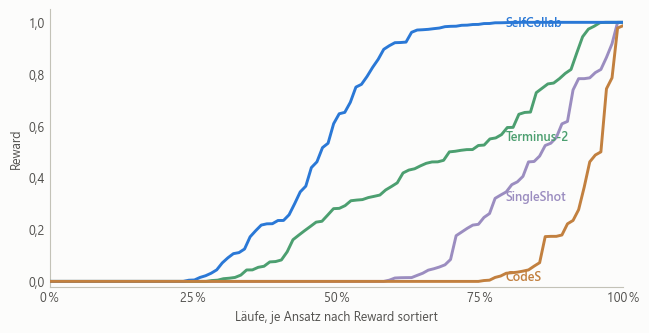

            mean_reward  median_reward  solved  zeros
SingleShot        0.162          0.000       3     61
Terminus-2        0.321          0.281       8     28
SelfCollab        0.531          0.628      43     25
CodeS             0.068          0.000       2     78

ranked by mean reward: SelfCollab > Terminus-2 > SingleShot > CodeS
quantiles at which that ordering fails: none


In [2]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.reward_curves(df), "reward-curves")
plt.show()

table = ja.compare(df)
print(table[["mean_reward", "median_reward", "solved", "zeros"]].round(3).to_string())
print()
# Whether the ordering really does hold everywhere, rather than only in the mean.
wide = ja.paired(df)
arms = list(wide.columns)
quantiles = [q / 20 for q in range(1, 20)]
curves = {arm: wide[arm].quantile(quantiles).to_numpy() for arm in arms}
ranking = table.mean_reward.sort_values(ascending=False).index
crossings = [
    (a, b) for a, b in zip(ranking, ranking[1:])
    if (curves[a] < curves[b]).any()
]
print(f"ranked by mean reward: {' > '.join(ranking)}")
print(f"quantiles at which that ordering fails: {crossings or 'none'}")

The same thing per task. Each cell counts the tasks on which the row arm scored strictly
above the column arm, out of the 100 both scored; the two never tie on more than a
quarter of them, and most ties are tasks where both scored nothing.

In [3]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)
wide = ja.paired(df)

print(f"tasks every arm scored: {len(wide)} of {df.task.nunique()}")
print()
print("tasks on which the row arm scored strictly higher")
print(ja.head_to_head(df).astype(object).fillna("-").to_string())
print()
best = wide.max(axis=1)
print(f"tasks nobody scored on at all : {int((best == 0).sum())}")
print(f"tasks nobody took above 0.5   : {int((best < 0.5).sum())}")
print(f"tasks some arm solved         : {int((best >= SOLVED_AT).sum())}")
print()
print("agreement between arms (Spearman, paired tasks)")
print(wide.corr(method="spearman").round(2).to_string())

tasks every arm scored: 100 of 104

tasks on which the row arm scored strictly higher
           SingleShot Terminus-2 SelfCollab CodeS
SingleShot          -         16         15    37
Terminus-2         57          -         37    65
SelfCollab         64         47          -    71
CodeS              12          9          2     -

tasks nobody scored on at all : 8
tasks nobody took above 0.5   : 36
tasks some arm solved         : 42

agreement between arms (Spearman, paired tasks)
arm         SingleShot  Terminus-2  SelfCollab  CodeS
arm                                                  
SingleShot        1.00        0.30        0.07   0.26
Terminus-2        0.30        1.00        0.09   0.01
SelfCollab        0.07        0.09        1.00   0.29
CodeS             0.26        0.01        0.29   1.00


## 4. Difficulty

Difficulty is the benchmark's own label, assigned from lines of code before any model saw
a task, so this is not a finding about the run so much as the axis the run is measured
along. It matters here for one reason: the arms do not degrade at the same rate, so the
gap between them depends on the difficulty mix of whatever subset they are compared on.

**A mean per band is not enough to read these distributions.** They are zero-inflated,
and several of them are bimodal — a block of finished packages and a block of wreckage,
with very little between. A mean sitting at 0.45 can describe a group in which almost no
trial scored anywhere near 0.45. The first figure therefore draws the quartiles, the
median, the mean and every individual trial, twelve groups in all; the second keeps the
means alone, because the *rate* at which each arm falls is a separate question from where
it sits, and the slopes answer it more directly than twelve boxes do.

wrote docs\figures\compare-difficulty-spread.png


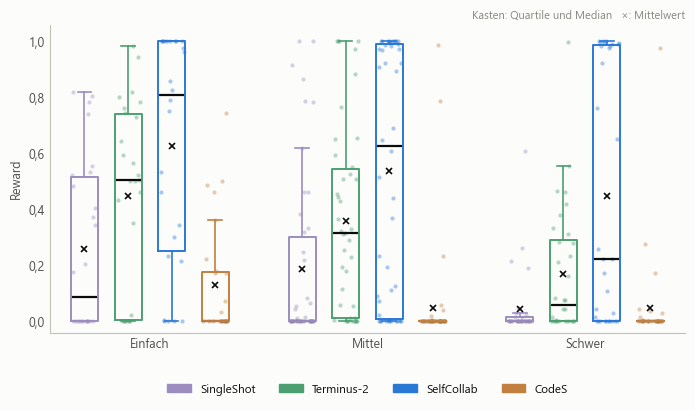

wrote docs\figures\compare-difficulty-slopes.png


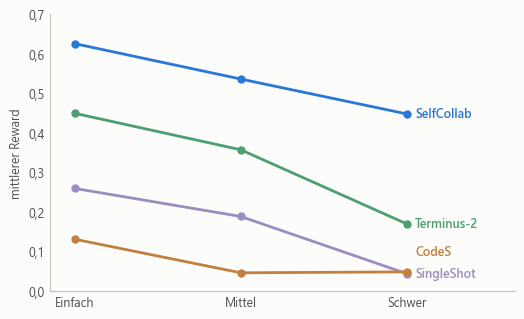

                        mean  median    std  size
arm        difficulty                            
CodeS      Easy        0.131   0.000  0.209    26
           Medium      0.046   0.000  0.186    46
           Hard        0.049   0.000  0.179    32
SelfCollab Easy        0.625   0.809  0.406    26
           Medium      0.536   0.628  0.444    46
           Hard        0.448   0.222  0.458    32
SingleShot Easy        0.260   0.088  0.305    26
           Medium      0.189   0.000  0.315    46
           Hard        0.044   0.000  0.122    32
Terminus-2 Easy        0.449   0.504  0.338    26
           Medium      0.357   0.315  0.338    42
           Hard        0.170   0.060  0.230    32

mean reward
arm         SingleShot  Terminus-2  SelfCollab  CodeS
difficulty                                           
Easy             0.260       0.449       0.625  0.131
Medium           0.189       0.357       0.536  0.046
Hard             0.044       0.170       0.448  0.049

kept on Hard, as

In [4]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.difficulty_spread(df), "difficulty-spread")
plt.show()

save(jf.difficulty_slopes(df), "difficulty-slopes")
plt.show()

# The gap between mean and median is what the boxes make visible: where they are
# far apart the band is bimodal and the mean describes very few of its trials.
spread = (df[df.scored].groupby(["arm", "difficulty"], observed=True)
          .reward.agg(["mean", "median", "std", "size"]).round(3))
print(spread.to_string())
print()

means = (df[df.scored].pivot_table(index="difficulty", columns="arm", values="reward",
                                   aggfunc="mean", observed=True)
         .reindex(index=ja.LEVELS, columns=ja.arm_order(df)))
print("mean reward")
print(means.round(3).to_string())
print()
print("kept on Hard, as a share of the same arm's Easy score")
print((means.loc["Hard"] / means.loc["Easy"]).round(2).to_string())
print()
print("tasks per level")
print(df[df.arm == ja.arm_order(df)[0]].difficulty.value_counts()
      .reindex(ja.LEVELS).to_string())

## 5. What the tokens bought

Consumption is counted in tokens rather than in money throughout. A bill depends on which
model was priced, at what rate, and on how much of the input was served from cache at a
discount — none of which is a property of the method being compared, and all of which
would change if these four jobs were re-run against a different model. `cost_usd` is
still on the frame for anyone who wants it.

Two figures rather than one, because scale and composition are different questions and an
earlier version of this section tried to answer both on a single axis and was unreadable.

**The first is scale**: mean reward beside total tokens — everything read and written,
which is the figure the run platform reports. A comparison quoting only output would
understate an agent loop that reads twenty times what it writes.

**The second is composition**, and it is the more interesting of the two. The totals hide
that the four arms spend their budgets on entirely different things. SingleShot puts
**72% of its tokens into output** — it is almost pure generation, because it makes one
request and never reads anything back. Terminus-2 is the mirror image: **94% is cached
input and barely 1% is output**, because an agent loop re-reads its whole transcript every
turn. SelfCollab and CodeS sit between, at 4% and 5% output.

That mix is what decides whether a large total is expensive. Terminus-2's 307.7M tokens
are mostly a transcript re-read at cache rates; SingleShot's 7.3M are mostly freshly
generated. Two totals forty times apart can cost about the same, which is precisely why
this notebook counts tokens and reports the mix rather than quoting a bill.

**Efficiency depends on which count you divide by, so both are reported.** Ranked by
output per solved task the order matches the reward ranking — SelfCollab 170k, Terminus-2
499k, SingleShot 1.7M, CodeS 9.8M. Ranked by total per solved task it does not, and
SingleShot moves ahead of both agent loops. Neither is wrong; `ja.compare` carries both.

**These totals are the platform's own.** `in_tok` is uncached plus cached input, which is
what Harbor splits across two columns; adding its three token columns gives exactly the
`total_tok` below. The checks at the end of this notebook assert that rather than
trusting it.

wrote docs\figures\compare-reward-and-tokens.png


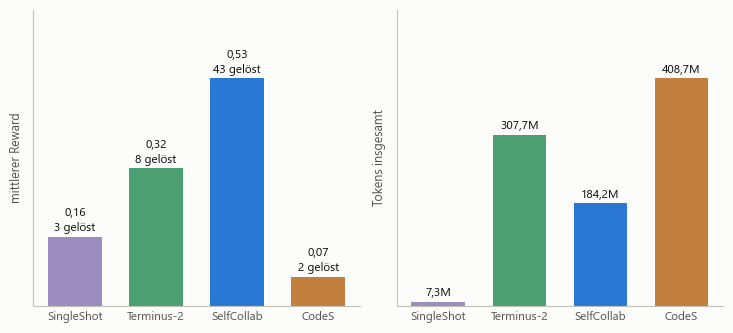

wrote docs\figures\compare-token-composition.png


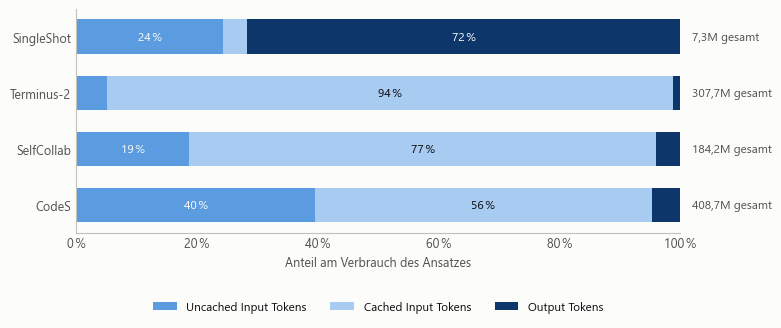

            mean_reward  solved  uncached_tok    cache_tok     out_tok    total_tok  cache_share  usage_reported
SingleShot        0.162       3     1783795.0     292608.0   5249289.0    7325692.0        0.141             104
Terminus-2        0.321       8    15994067.0  287698176.0   3993127.0  307685370.0        0.947             104
SelfCollab        0.531      43    34571372.0  142319104.0   7318811.0  184209287.0        0.805             104
CodeS             0.068       2   161623230.0  227463424.0  19590246.0  408676900.0        0.585              96



what each arm's consumption is made of
  SingleShot : 24.3% new input,  4.0% cached input, 71.7% output
  Terminus-2 :  5.2% new input, 93.5% cached input,  1.3% output
  SelfCollab : 18.8% new input, 77.3% cached input,  4.0% output
  CodeS      : 39.5% new input, 55.7% cached input,  4.8% output

  SingleShot : input    2.1M (14.1% cached)   output    5.2M   per solved:    1.7M out,    2.4M total
  Terminus-2 : input  303.7M (94.7% cached)   output      4M   per solved:  499.1k out,   38.5M total
  SelfCollab : input  176.9M (80.5% cached)   output    7.3M   per solved:  170.2k out,    4.3M total
  CodeS      : input  389.1M (58.5% cached)   output   19.6M   per solved:    9.8M out,  204.3M total

leanest first, by output tokens per solved task: SelfCollab < Terminus-2 < SingleShot < CodeS
leanest first, by total tokens per solved task: SingleShot < SelfCollab < Terminus-2 < CodeS

  SingleShot :    4.8M of    7.3M bought no passing test (65%)
  Terminus-2 :   88.8M of  307.7M boug

In [5]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.reward_and_tokens(df), "reward-and-tokens")
plt.show()

save(jf.token_composition(df), "token-composition")
plt.show()

table = ja.compare(df)
print(table[["mean_reward", "solved", "uncached_tok", "cache_tok", "out_tok",
             "total_tok", "cache_share", "usage_reported"]].round(3).to_string())
print()
print("what each arm's consumption is made of")
for arm, row in table.iterrows():
    print(f"  {arm:11s}: {row.uncached_tok / row.total_tok:5.1%} new input,"
          f" {row.cache_tok / row.total_tok:5.1%} cached input,"
          f" {row.out_tok / row.total_tok:5.1%} output")
print()
for arm, row in table.iterrows():
    print(f"  {arm:11s}: input {ja.fmt_tokens(row.in_tok):>7s}"
          f" ({row.cache_share:5.1%} cached)   output {ja.fmt_tokens(row.out_tok):>7s}"
          f"   per solved: {ja.fmt_tokens(row.out_per_solved):>7s} out,"
          f" {ja.fmt_tokens(row.total_per_solved):>7s} total")
print()
# The two denominators rank the arms differently, which is the reason to print both.
for label, column in (("output tokens per solved task", "out_per_solved"),
                      ("total tokens per solved task", "total_per_solved")):
    order = table[column].sort_values().index
    print(f"leanest first, by {label}: {' < '.join(order)}")
print()
for arm in ja.arm_order(df):
    part = df[df.arm == arm]
    wasted = part.loc[~part.outcome.isin(ja.EARNED), "total_tok"].sum()
    print(f"  {arm:11s}: {ja.fmt_tokens(wasted):>7s} of"
          f" {ja.fmt_tokens(part.total_tok.sum()):>7s} bought no passing test"
          f" ({wasted / part.total_tok.sum():.0%})")

## 6. How long a run takes

Time is a third cost, independent of the other two: an arm can be cheap in tokens and slow
in wall clock, or the reverse. The figure draws the quartiles and the median as a box with
every trial over it, because these four distributions are not the same shape and a box
alone would say they were.

**Read wall clock as latency, not as compute.** Only CodeS runs its requests concurrently
— forty at a time, from its own `concurrent_requests`; the other three are sequential. So
CodeS finishing a median trial in 9.3 minutes against SelfCollab's 6.6 does not mean it
did half again as much work in that time. It means it did fifty-six times the tokens, in
parallel. Tokens answer the compute question; this figure answers how long you wait.

Three shapes worth naming:

- **SingleShot is fast and then not.** A median of 2.4 minutes with a quarter of its
  trials past 9, and the dark points sit to the right — its runtime tracks the size of the
  task (rank correlation with difficulty +0.54), because a bigger repository means a
  longer reply.
- **SelfCollab is the most predictable.** The tightest box of the four, and runtime that
  barely responds to difficulty at all (−0.08) — three rounds of fixed step budgets cost
  what they cost whatever the task is.
- **CodeS has the longest tail and the only censoring.** A third of its trials run over 15
  minutes and six sit exactly on the harness deadline, drawn in red.

**Spending longer never bought more.** Within every arm the rank correlation between
runtime and reward is negative, from −0.06 to −0.40. A long run is a symptom of trouble
rather than of thoroughness — most clearly for SelfCollab at −0.40, whose slow trials are
its failures.

wrote docs\figures\compare-runtime-spread.png


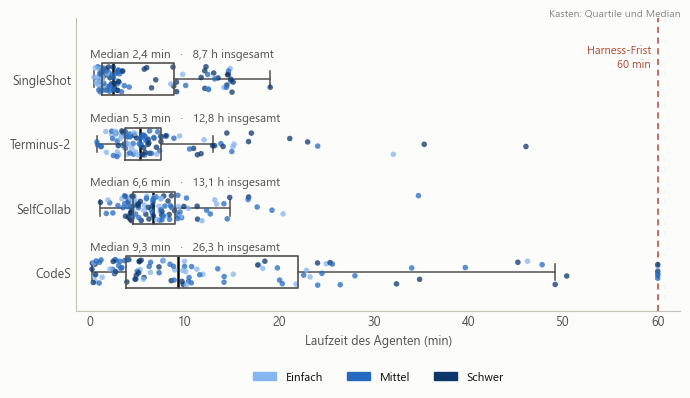

agent wall clock, minutes
             min   25%   50%    75%    90%    max
arm                                              
SingleShot  0.40  1.27  2.45   8.91  14.32  19.03
Terminus-2  0.71  3.73  5.30   7.49  14.81  46.07
SelfCollab  1.09  4.48  6.64   9.00  13.03  34.70
CodeS       0.19  3.81  9.32  21.96  43.54  60.00

            median_minutes  total_hours
SingleShot            2.45         8.74
Terminus-2            5.30        12.81
SelfCollab            6.64        13.08
CodeS                 9.32        26.25

rank correlations within each arm
  SingleShot : runtime vs reward -0.11   runtime vs difficulty +0.54
  Terminus-2 : runtime vs reward -0.06   runtime vs difficulty +0.36
  SelfCollab : runtime vs reward -0.40   runtime vs difficulty -0.08
  CodeS      : runtime vs reward -0.30   runtime vs difficulty -0.05

median minutes by difficulty
arm         SingleShot  Terminus-2  SelfCollab  CodeS
difficulty                                           
Easy               1.1  

In [6]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.runtime_spread(df), "runtime-spread")
plt.show()

minutes = (df.t_agent / 60).groupby(df.arm, observed=True).describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]).reindex(ja.arm_order(df))
print("agent wall clock, minutes")
print(minutes[["min", "25%", "50%", "75%", "90%", "max"]].round(2).to_string())
print()
print(ja.compare(df)[["median_minutes", "total_hours"]].round(2).to_string())
print()
# Rank correlation without scipy: Pearson on ranks is Spearman by definition.
print("rank correlations within each arm")
for arm in ja.arm_order(df):
    part = df[(df.arm == arm) & df.scored]
    print(f"  {arm:11s}: runtime vs reward {part.t_agent.rank().corr(part.reward.rank()):+.2f}"
          f"   runtime vs difficulty "
          f"{part.t_agent.rank().corr(part.difficulty.cat.codes.rank()):+.2f}")
print()
print("median minutes by difficulty")
print(df.assign(minutes=df.t_agent / 60).pivot_table(
    index="difficulty", columns="arm", values="minutes", aggfunc="median",
    observed=True).reindex(columns=ja.arm_order(df)).round(1).to_string())
print()
# Wall clock and tokens are different costs, and concurrency is why.
print("throughput, tokens per second of agent time")
for arm in ja.arm_order(df):
    part = df[df.arm == arm]
    print(f"  {arm:11s}: {part.total_tok.sum() / part.t_agent.sum():7.0f} total/s,"
          f" {part.out_tok.sum() / part.t_agent.sum():6.0f} output/s")

## 7. What the trials produced

Two arms can share a mean and have earned it in entirely different ways — a body of
half-working packages, or a block of finished ones beside a block of wreckage. Splitting
every arm's trials by what they produced separates those, and it uses the same four
failure stages the run notebooks use, so a bar here and a bar there mean the same thing.

wrote docs\figures\compare-outcome-mix.png

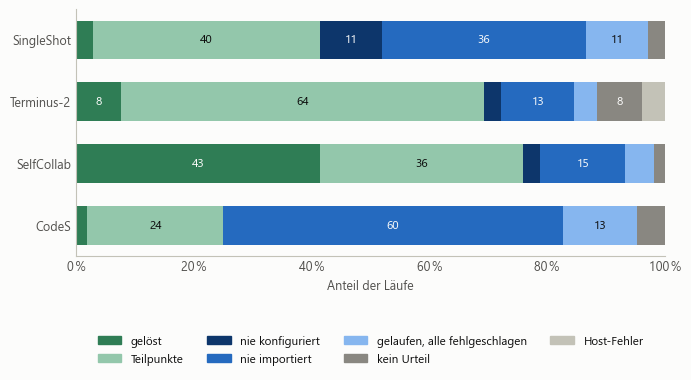

arm                 SingleShot  Terminus-2  SelfCollab  CodeS
outcome                                                      
solved                       3           8          43      2
partial credit              40          64          36     24
never configured            11           3           3      0
never imported              36          13          15     60
ran, all failed             11           4           5     13
no verdict                   3           8           2      5
lost to host fault           0           4           0      0

as a share of each arm's trials
arm                 SingleShot  Terminus-2  SelfCollab  CodeS
outcome                                                      
solved                   0.029       0.077       0.413  0.019
partial credit           0.385       0.615       0.346  0.231
never configured         0.106       0.029       0.029  0.000
never imported           0.346       0.125       0.144  0.577
ran, all failed          0.106       

In [7]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.outcome_mix(df), "outcome-mix")
plt.show()

mix = ja.outcome_mix(df)
print(mix.to_string())
print()
print("as a share of each arm's trials")
print((mix / mix.sum()).round(3).to_string())

## 8. Every cause of a zero, pooled

Each run notebook counts its own arm's causes; nothing so far has counted the taxonomy as
a whole. Pooling all 192 zeros across the four arms answers two questions at once — which
mistakes dominate the benchmark, and whether a given mistake belongs to one method or to
all of them.

Both answers are worth having. The commonest single cause is a package the agent wrote
but laid out so that its own imports do not resolve, and every arm makes it. The second,
third and fourth are concentrated almost entirely in two arms, which is the subject of
the next section. And one cause is the property of a single arm: only Terminus-2 builds
the whole project one directory too deep, nine times, which is a hazard of having a shell
and a working directory at all.

Colour is the arm here rather than the failure stage — stage is what section 6 shows.
Passing `top=N` keeps only the commonest causes if the tail of singletons is not wanted.

wrote docs\figures\compare-cause-overview.png


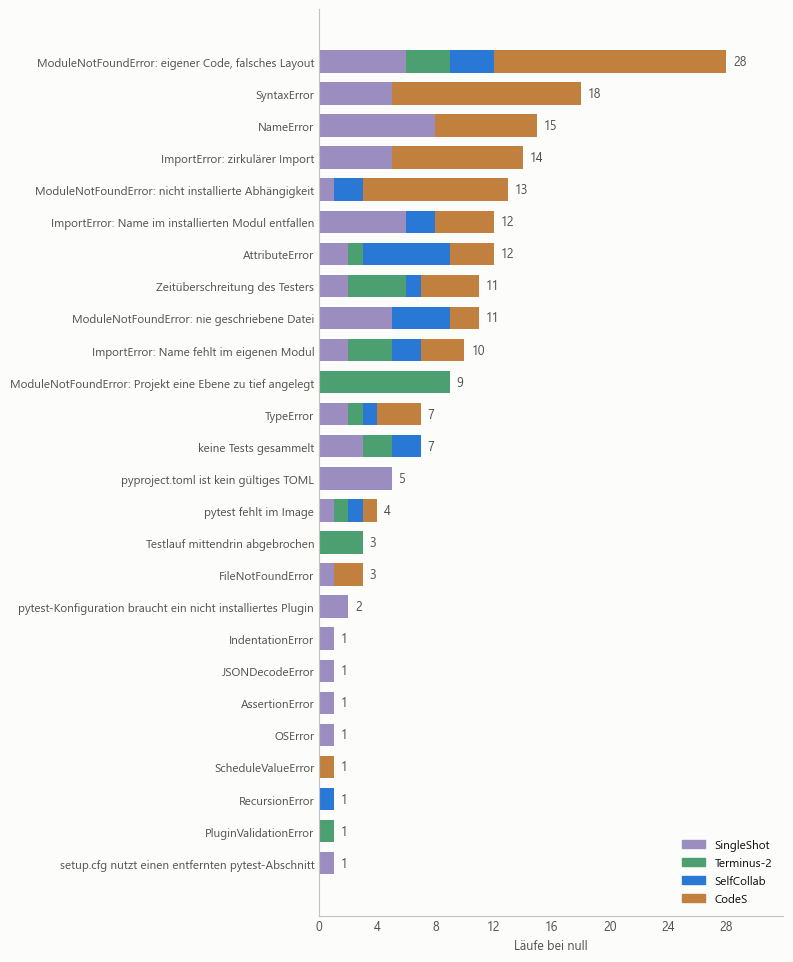

arm                                                    SingleShot  Terminus-2  SelfCollab  CodeS  gesamt
fault_cause                                                                                             
ModuleNotFoundError: own code, wrong layout                     6           3           3     16      28
SyntaxError                                                     5           0           0     13      18
NameError                                                       8           0           0      7      15
ImportError: circular import                                    5           0           0      9      14
ModuleNotFoundError: uninstalled dependency                     1           0           2     10      13
ImportError: name gone from an installed module                 6           0           2      4      12
AttributeError                                                  2           1           6      3      12
tester timed out                                       

In [8]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.cause_overview(df), "cause-overview")
plt.show()

table = ja.cause_by_arm(df)
table["gesamt"] = table.sum(axis=1)
print(table.sort_values("gesamt", ascending=False).to_string())
print()

zeros = df[df.scored & (df.reward == 0)]
print(f"zeros in total: {len(zeros)} over {int(df.scored.sum())} scored trials")
print(f"distinct causes: {zeros.fault_cause.nunique()}")
print()
# A cause only one arm ever hits says something about that arm specifically.
counts = ja.cause_by_arm(df)
exclusive = counts[(counts > 0).sum(axis=1) == 1]
print("causes that only one arm ever hit")
for cause, row in exclusive[exclusive.sum(axis=1) >= 2].iterrows():
    arm = row.idxmax()
    print(f"  {int(row.max()):3d}x  {arm:11s}  {cause}")

## 9. The one mechanism that explains most of the gap

The zeros are already classified by cause, identically for every arm, so they can be
asked a question no single-arm notebook can ask: **do the arms fail in different ways, or
in the same way at different rates?**

Different ways, and the split is not subtle. Four causes stand out —

- `SyntaxError` — the file does not parse.
- `IndentationError` — likewise.
- `NameError` — a name is used that was never defined.
- `ImportError: circular import` — the package cannot import itself.

None of these needs the specification, the hidden tests, or any judgement to find.
Running the generated code once is enough to surface every one of them. They are
collected in `ja.EXECUTION_CATCHABLE` for exactly that reason.

Two of the four arms have a shell and use it: Terminus-2 runs commands as it works, and
SelfCollab's Tester runs the project's own test command between Coder rounds. The other
two never execute what they write — SingleShot emits one reply, and CodeS fills function
bodies into a sketch and stops.

The four causes appear **48 times, and never once in the two arms that run their code.**

wrote docs\figures\compare-execution-gap.png


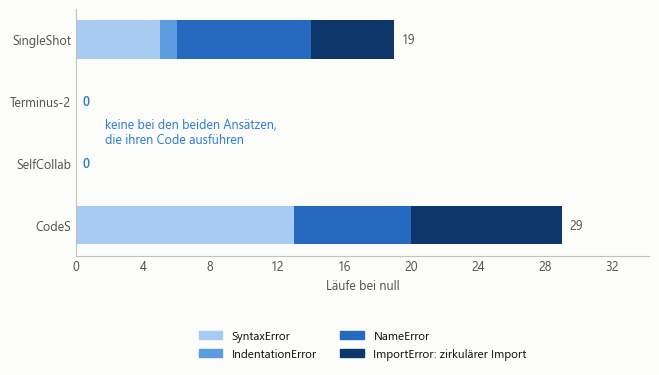

arm                           SingleShot  Terminus-2  SelfCollab  CodeS
fault_cause                                                            
SyntaxError                            5           0           0     13
IndentationError                       1           0           0      0
NameError                              8           0           0      7
ImportError: circular import           5           0           0      9

share of each arm's zeros that one execution would have caught
arm
SingleShot    0.31
Terminus-2    0.00
SelfCollab    0.00
CodeS         0.37

48 of 192 zeros across all four arms

what the arms with a shell fail on instead, most common first
fault_cause
ModuleNotFoundError: project built one level too deep    9
AttributeError                                           7
ModuleNotFoundError: own code, wrong layout              6
tester timed out                                         5
ImportError: name missing from its own module            5
no tests were co

In [9]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.execution_gap(df), "execution-gap")
plt.show()

table = ja.cause_by_arm(df, ja.EXECUTION_CATCHABLE)
print(table.to_string())
print()
zeros = df[df.scored & (df.reward == 0)]
caught = zeros.fault_cause.isin(ja.EXECUTION_CATCHABLE)
print("share of each arm's zeros that one execution would have caught")
share = (zeros[caught].groupby("arm", observed=True).size()
         / zeros.groupby("arm", observed=True).size())
print(share.reindex(ja.arm_order(df)).fillna(0).round(2).to_string())
print()
print(f"{int(caught.sum())} of {len(zeros)} zeros across all four arms")
print()
# The claim is about these four causes and not about zeros in general: the two
# arms with a shell fail plenty, just never in these four ways.
print("what the arms with a shell fail on instead, most common first")
shell = [a for a in ja.arm_order(df) if table[a].sum() == 0]
print(zeros[zeros.arm.isin(shell)].fault_cause.value_counts().head(6).to_string())

It is worth being precise about what this does and does not show.

**It is not that the two arms with a shell fail less.** They fail on 28 and 25 tasks
respectively, which is a quarter of the benchmark. They fail on *other* things —
attributes that do not exist, packaging layouts that do not import, tests that run and
disagree with the answer. Those are all failures that survive an execution.

**It is not a controlled experiment.** The four arms differ in more than whether they run
their code, and this cannot separate "executes its output" from everything else that
comes with an agent loop. What it does establish is that a whole class of failure is
absent from one pair and common in the other, and that the class is precisely the one a
single execution removes.

**The cheapest reading is the useful one.** For SingleShot and CodeS, 19 and 29 zeros are
not evidence that the model cannot write the package. They are evidence that nothing
checked whether the file parsed.

## 10. Does any arm add something the others do not?

A comparison that only ranks arms answers "which one should be run". Pairing lets a
second question be asked: what would be given up by not running each of them at all.

`ja.oracle` answers it by picking the best arm per task — the upper bound available from
this set — and then recomputing it with one arm removed. The difference is that arm's
marginal contribution. An arm can score respectably in isolation and contribute nothing,
if every task it does well is a task another arm does at least as well.

wrote docs\figures\compare-solved-overlap.png


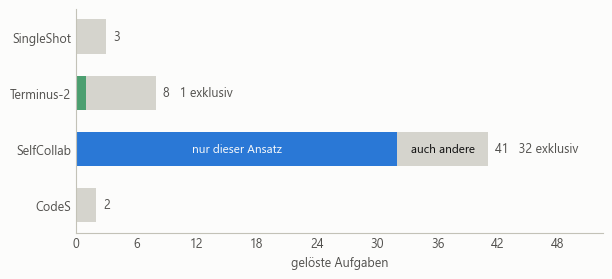

picking the best arm per task, over the tasks every arm scored
                    mean_reward  solved  reward_lost  solved_lost
all arms                 0.6407      42       0.0000            0
without SingleShot       0.6373      42       0.0033            0
without Terminus-2       0.5681      41       0.0726            1
without SelfCollab       0.3932      10       0.2475           32
without CodeS            0.6407      42       0.0000            0

            only this arm  also solved elsewhere
SingleShot              0                      3
Terminus-2              1                      7
SelfCollab             32                      9
CodeS                   0                      2

  SingleShot : beats the best of the other three on  5 of 100 tasks
  Terminus-2 : beats the best of the other three on 32 of 100 tasks
  SelfCollab : beats the best of the other three on 44 of 100 tasks
  CodeS      : beats the best of the other three on  0 of 100 tasks


In [10]:
df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

save(jf.solved_overlap(df), "solved-overlap")
plt.show()

print("picking the best arm per task, over the tasks every arm scored")
print(ja.oracle(df).round(4).to_string())
print()
print(ja.solved_alone(df).to_string())
print()
wide = ja.paired(df)
for arm in wide.columns:
    others = wide[[c for c in wide.columns if c != arm]].max(axis=1)
    print(f"  {arm:11s}: beats the best of the other three on"
          f" {int((wide[arm] > others).sum()):2d} of {len(wide)} tasks")

## 11. What these four jobs will not support

Four things are easy to read off this data and would be wrong.

**`hit_budget` is not one quantity.** The column exists for every arm and means a
different event in each: the reply was cut at the output ceiling (SingleShot, 27), the
loop was stopped mid-command (Terminus-2, 13), the round loop never satisfied its own
tester (SelfCollab, 89), the pipeline never reached its own `Done` (CodeS, 76). Those
counts must not be put in one chart. `ending` is the readable form and is printed below
per arm.

**One task is ungradeable.** `more-Itertools` scores 0.978 for CodeS against a workspace
containing no files at all, because its hidden tests import the `more_itertools` already
installed in the image rather than the generated code. SelfCollab records the identical
0.978006. Every figure above includes it, so that the numbers here reconcile with the
four run notebooks; the cell below shows what it is worth. It changes no ranking.

**CodeS's token total is a floor, but only just.** Eight of its trials recorded no usage
at all — killed by the harness before the runner wrote its usage file — so 408.7M is the
total over 96 trials, not 104. Those eight died early, after 13 to 72 model requests each
against a median near 170 for a recorded trial; at the run's own average of ~25k tokens
per request they account for roughly 6.7M tokens, about 1.6% of the recorded total. The
platform's summary carries the same gap, because it sums the same records. Every other
arm reported usage for all 104 trials.

**Terminus-2's mean is over 100 trials, not 104.** Four were lost to host faults and
carry no reward at all rather than a zero, which is why the paired comparisons run over
100 tasks.

In [11]:
import pandas as pd

df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

print("how each arm's runs ended — the same column, four different events")
for arm in ja.arm_order(df):
    part = df[df.arm == arm]
    print(f"\n{arm}  (hit_budget on {int(part.hit_budget.sum())} of {len(part)},"
          f" meaning: {part.budget_name.iloc[0]} reached)")
    print(part.groupby("ending").agg(
        trials=("reward", "size"), mean_reward=("reward", "mean"),
        zeros=("reward", lambda s: int((s == 0).sum()))).round(3).to_string())

print("\n" + "-" * 62)
print("the ungradeable task, and what dropping it is worth")
UNGRADEABLE = ["more-Itertools"]
print(df[df.task.isin(UNGRADEABLE)][
    ["arm", "task", "reward", "workspace_files", "n_hidden_tests"]].to_string(index=False))
print()
kept = df[~df.task.isin(UNGRADEABLE)]
for arm in ja.arm_order(df):
    a, b = df[(df.arm == arm) & df.scored], kept[(kept.arm == arm) & kept.scored]
    print(f"  {arm:11s}: mean {a.reward.mean():.3f} -> {b.reward.mean():.3f}"
          f"   solved {int(a.solved.sum()):2d} -> {int(b.solved.sum()):2d}")
print()
# The signature is a high score with nothing on disk. Only that one task shows it.
suspect = df[(df.reward > 0.5) & (df.workspace_files < 5)]
print("every trial scoring above 0.5 with fewer than five files written:")
print(suspect[["arm", "task", "reward", "workspace_files"]].to_string(index=False))

how each arm's runs ended — the same column, four different events

SingleShot  (hit_budget on 27 of 104, meaning: max_tokens reached)
                           trials  mean_reward  zeros
ending                                               
cut at the output ceiling      27        0.102     19
reply finished                 77        0.183     42

Terminus-2  (hit_budget on 13 of 104, meaning: max_turns reached)
                     trials  mean_reward  zeros
ending                                         
cut at turn ceiling      13        0.200      4
declared complete        87        0.339     24
lost to host fault        4          NaN      0

SelfCollab  (hit_budget on 89 of 104, meaning: max_rounds reached)
                                       trials  mean_reward  zeros
ending                                                           
passed its own tests at round 1             5        0.963      0
passed its own tests at round 2            10        0.735      1
used every

## 12. Checks

**The rewards are what they claim to be.** Reward arrives as a float in each
`result.json`, computed inside the container. pytest's own summary line, parsed
independently out of a different file, agrees with it closely for every arm.

**Every zero was classified.** A zero the classifier could not read would be filed as
`unclassified`; the count of those is printed per arm, so a gap in the taxonomy cannot
pass as a clean result.

**The arms were read by the same code.** Every column used above is in
`ja.COMMON_COLUMNS`, which each arm's reader fills identically. Nothing arm-specific
enters a comparison.

In [12]:
import pandas as pd

df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

for arm in ja.arm_order(df):
    part = df[df.arm == arm]
    ran = part[part.scored & part.pt_ran].copy()
    units = (ran.pt_passed + ran.pt_failed + ran.pt_error).replace(0, pd.NA)
    ran["pytest_fraction"] = ran.pt_passed / units
    agree = ran.dropna(subset=["pytest_fraction"])
    zeros = part[part.scored & (part.reward == 0)]
    print(f"{arm:11s}: r = {agree.reward.corr(agree.pytest_fraction):.3f}"
          f"  (n={len(agree)})   median gap"
          f" {(agree.reward - agree.pytest_fraction).abs().median():.3f}"
          f"   unclassified zeros"
          f" {int((zeros.fault_cause == 'unclassified').sum())} of {len(zeros)}")

print()
# The token columns are the platform's own numbers, not a re-derivation: input is
# uncached plus cached, and the three counts it reports sum to `total_tok`.
for arm in ja.arm_order(df):
    part = df[df.arm == arm]
    stated = part.total_tok.sum()
    rebuilt = part.in_tok.sum() + part.out_tok.sum()
    cached_within_input = bool((part.cache_tok.fillna(0) <= part.in_tok.fillna(0)).all())
    print(f"{arm:11s}: in + out = total ({stated == rebuilt}),"
          f" cache within input ({cached_within_input}),"
          f" {ja.fmt_tokens(stated)} over {int(part.total_tok.notna().sum())} trials")

print()
missing = [c for c in ja.COMMON_COLUMNS if c not in df.columns]
print(f"common columns present for every arm: {not missing}"
      + (f"  missing {missing}" if missing else ""))
print("columns used above that are arm-specific: none by construction")

SingleShot : r = 0.972  (n=78)   median gap 0.000   unclassified zeros 0 of 61
Terminus-2 : r = 0.981  (n=74)   median gap 0.000   unclassified zeros 0 of 28
SelfCollab : r = 0.945  (n=89)   median gap 0.000   unclassified zeros 0 of 25
CodeS      : r = 0.962  (n=78)   median gap 0.000   unclassified zeros 0 of 78

SingleShot : in + out = total (True), cache within input (True), 7.3M over 104 trials
Terminus-2 : in + out = total (True), cache within input (True), 307.7M over 104 trials
SelfCollab : in + out = total (True), cache within input (True), 184.2M over 104 trials
CodeS      : in + out = total (True), cache within input (True), 408.7M over 96 trials

common columns present for every arm: True
columns used above that are arm-specific: none by construction


## 13. The table for the write-up

The paper needs one compact table of these numbers, and a table pasted in as literal
digits goes stale the moment a job is re-run without anything warning you. `job_tables`
generates it from the same frame the figures are drawn from, so the table in the document
and the figures beside it cannot disagree.

Everything the reader sees is German — headers, decimal comma, thousands separator,
budget wording and notes — while the frame underneath stays English, exactly as it does
for the figures.

**The notes are derived, not typed.** Which arms lost trials to a host fault, which
recorded no usage, and what dropping the ungradeable task is worth are all counted from
the data at generation time, so a note cannot outlive the caveat it describes.

`columns=` picks and orders the columns from `jt.COLUMNS` — the default is the eight that
fit `	extwidth` at `ootnotesize`, and `total_tok`, `total_per_solved` and
`median_minutes` are available for a wider or a differently-argued table.

The second table crosses consumption with the result it bought, collapsing the outcome
taxonomy to the three classes the write-up uses: **Null** (reward exactly 0), **Teilerfolg**
(between 0 and the solved threshold) and **Gelöst**. It answers the question the headline
table cannot — not what an arm consumed, but what the consumption returned.

Shares are of each arm's own budget, because the arms differ by a factor of 56 in absolute
tokens and a share of the grand total would only say which arm is biggest. Read that way:

- **SingleShot and CodeS spend most of their budget on nothing** — 65,2\,% and 78,5\,% of
  their tokens go to trials that score zero.
- **SelfCollab is the only arm where a third of the budget reaches a solved task**
  (33,6\,%, against 3,1\,%, 3,5\,% and 1,2\,% for the others).
- **Terminus-2's budget goes overwhelmingly to partial credit** — 67,7\,%, which is the
  token form of the shape already visible in its reward curve.

And one finding that is not visible in any share: in three of the four arms a trial that
scores nothing consumes **more** tokens at the median than one that is solved. Failure is
not the cheaper outcome — a run that is going wrong spends its budget flailing.

In [13]:
import job_tables as jt

df = ja.load_jobs(JOBS, solved_at=SOLVED_AT)

latex = jt.summary_latex(df, solved_at=SOLVED_AT)
jt.write(latex, "kennzahlen-arme")
print()
print(latex)
print()

cross = jt.tokens_by_class_latex(df, solved_at=SOLVED_AT)
jt.write(cross, "tokens-ergebnisklasse")
print()
print(cross)
print()

# The frame the table is built from, for reading rather than typesetting.
table = ja.tokens_by_class(df)
print("tokens by result class")
print(table.round(3).to_string())
print()
print("median tokens per trial: a zero against a solve")
for arm in ja.arm_order(df):
    row = table.loc[arm]
    print(f"  {arm:11s}: Null {ja.fmt_tokens(row[('zero', 'median')]):>7s}"
          f"   Gelöst {ja.fmt_tokens(row[('solved', 'median')]):>7s}")

wrote docs\tables\kennzahlen-arme.tex

\begin{table}[H]
  \centering
  \begin{threeparttable}
    \caption[Kennzahlen der vier Codegenerierungs-Ansätze]{Ergebnisse der vier Codegenerierungs-Ansätze auf NL2RepoBench. Je Ansatz ein Durchlauf über alle 104 Aufgaben mit demselben Modell, absteigend nach mittlerem Reward.}
    \label{tab:kennzahlen-arme}
    \footnotesize
    \begin{tabularx}{\textwidth}{@{}lXrrrrrr@{}}
      \toprule
      Ansatz & Budget & \multicolumn{2}{c}{Reward} & Gelöst & Null & \multicolumn{2}{c}{Output Tokens} \\ \cmidrule(lr){3-4}\cmidrule(lr){7-8}
       &  & $\varnothing$ & Md &  &  & gesamt & je Lösung \\
      \midrule
      SelfCollab & 3 Runden & 0,53 & 0,63 & 43 & 25 & 7,3\,M & 170,2\,k \\
      Terminus-2\tnote{a} & 58 Turns & 0,32 & 0,28 & 8 & 28 & 4,0\,M & 499,1\,k \\
      SingleShot & 131\,100 Ausgabe-Tokens & 0,16 & 0,00 & 3 & 61 & 5,2\,M & 1,7\,M \\
      CodeS\tnote{b} & 4\,000\,000 Tokens & 0,07 & 0,00 & 2 & 78 & 19,6\,M & 9,8\,M \\
      \bottomru

## What this comparison says

**SelfCollab wins on every measure taken here, and not narrowly.** Mean reward 0.53
against 0.32, 0.16 and 0.07; 43 tasks solved against 8, 3 and 2; and it does it for
7.3M output tokens, which is under half of what the weakest arm generates. Its curve is
above every other
arm's at every quantile, and it beats each of them head-to-head on 47, 64 and 71 of the
100 shared tasks.

**Output tokens per solved task span 58x.** 170k for SelfCollab, 499k for Terminus-2,
1.7M for SingleShot, 9.8M for CodeS. Total output does not: three of the arms generate
between 4.0M and 7.3M, so this is a difference in what the generation bought and not in
how much of it there was. CodeS is the exception on both counts, producing 19.6M output
tokens — more than the other three combined — for two solved tasks.

**On total tokens the ranking changes, and that is worth knowing before quoting either.**
Counting everything read as well as written, SingleShot is the leanest per solved task at
2.4M, ahead of SelfCollab at 4.3M and far ahead of Terminus-2 at 38.5M. The agent loops
re-read their context every turn — Terminus-2 takes in 304M input tokens against 4M
written — and 95% of that input is served from cache. Whether that re-reading should
count against a method is a judgement, not a measurement, so both denominators are in the
table.

**The gap is mostly one mechanism.** 48 zeros across the run are files that do not parse,
names that were never defined, and packages that cannot import themselves. Not one of
them belongs to an arm that runs its own code. For SingleShot and CodeS that is 19 and 29
zeros — 31% of SingleShot's and 37% of CodeS's — attributable to nothing
having checked that the output was valid Python. This is the cheapest available
improvement to either arm and does not require a better model.

**SelfCollab also degrades most gracefully.** It keeps 72% of its Easy score on Hard;
Terminus-2 keeps 38%, CodeS 37%, SingleShot 17%. The ranking therefore widens on the hard
half of the benchmark and narrows on the easy half, which matters for any comparison run
on a subset — including the balanced one in `nl2repobench-subset-selection.ipynb`.

**Only two of the four arms are worth running.** Picking the best arm per task would
score 0.641 and solve 42 of 100. Removing CodeS from that set changes it by exactly
nothing: it never beats the best of the other three on any task. Removing SingleShot
costs 0.003 and no solved tasks. Removing Terminus-2 costs 0.073 and one. Removing
SelfCollab costs 0.247 and 32 — it alone solves 32 tasks no other arm solves.

**Nothing here separates the method from its budget.** Each arm ran at its own
configured limits, and the two weakest are also the two that never execute their output;
whether a method or its budget is responsible cannot be answered from four single runs of
104 tasks each. What can be said is that these four configurations, at these token
budgets, rank in this order — and that one of them is dominated outright.